In [234]:
import corner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy
import scipy.signal as signal
from scipy.stats import norm
import math
from tqdm import tqdm
#!jt -t chesterish -T -N -kl

In [235]:
# IMPORT DATA
data = np.loadtxt("data.dat")

time = data[:,0] # [d]
flux = data[:,1]
fluxErr = data[:,2]
tpivot = np.median(time)
time = time - tpivot

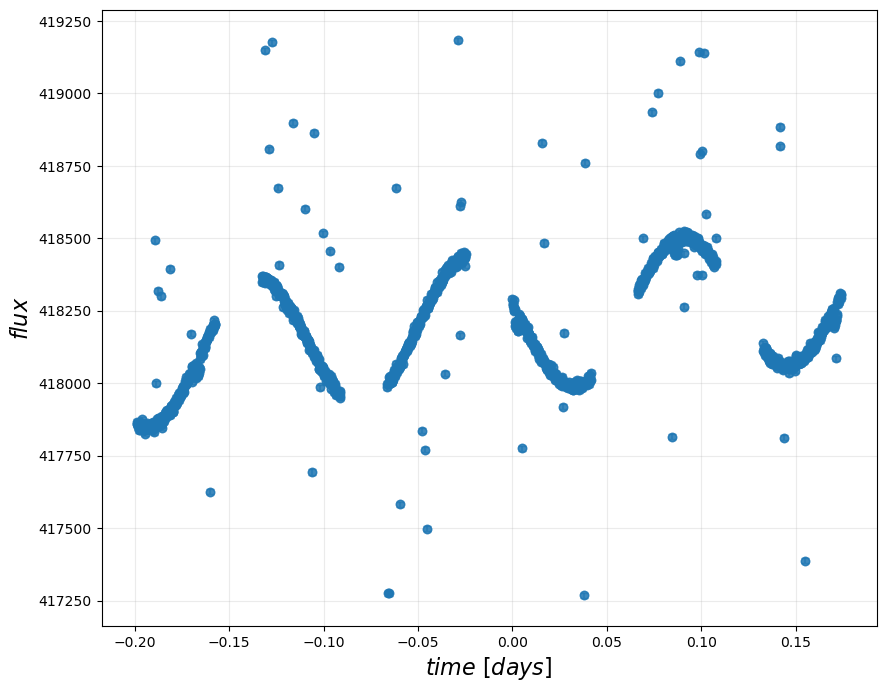

In [236]:
plt.figure(figsize=(10,8))
#plt.plot(x, result, color='k')
plt.scatter(time, flux, alpha=0.65, zorder=10)
plt.errorbar(time, flux, yerr=fluxErr, fmt="o", capsize=3, alpha=0.6)
plt.grid(alpha=0.25)
plt.ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)
#plt.xlim([left, right])

plt.savefig("RawData.png", dpi=300)

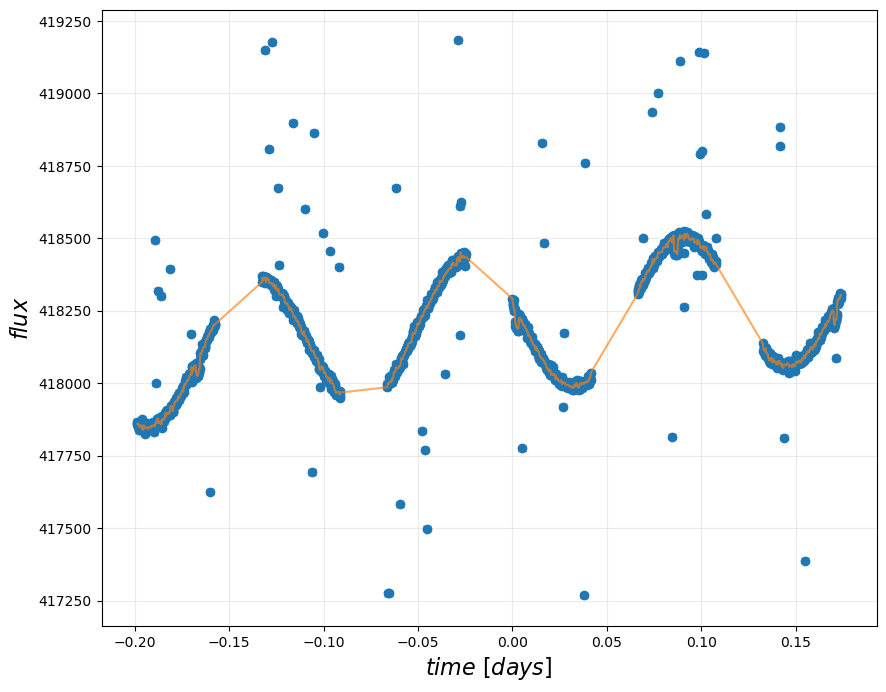

In [237]:
DataDF = pd.DataFrame({'time':time,'flux':flux,'fluxErr':fluxErr})

window = 5
DataDF['rollingFlux'] = DataDF['flux'].rolling(window).median()
DataDF['rollingTime'] = DataDF['time'].rolling(window).median()

plt.figure(figsize=(10,8))
plt.autoscale(enable=True, axis=u'both', tight=False)

plt.errorbar(DataDF['time'], DataDF['flux'], yerr=DataDF['fluxErr'], fmt="o", capsize=3, alpha=1)
plt.plot(DataDF['rollingTime'], DataDF['rollingFlux'], alpha=0.65, zorder=10)

plt.ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)

plt.grid(True, alpha=0.25)

plt.savefig("MovingMedian.png", dpi=300)

In [238]:
DataDF[:10] # CHECK ABOUT MEDIAN CUTOFF

,time,flux,fluxErr,rollingFlux,rollingTime
0,-0.198917,417859.682517,8.864388,NaN,NaN
1,-0.198764,417859.298198,8.864388,NaN,NaN
2,-0.198611,417866.679886,8.864388,NaN,NaN
3,-0.198458,417860.918968,8.864388,NaN,NaN
4,-0.198306,417859.424225,8.864388,417859.682517,-0.198611
5,-0.198153,417860.691147,8.864388,417860.691147,-0.198458
6,-0.198000,417848.666987,8.864388,417860.691147,-0.198306
7,-0.197847,417857.860721,8.864388,417859.424225,-0.198153
8,-0.197694,417838.102040,8.864388,417857.860721,-0.198000
9,-0.197542,417855.245755,8.864388,417855.245755,-0.197847


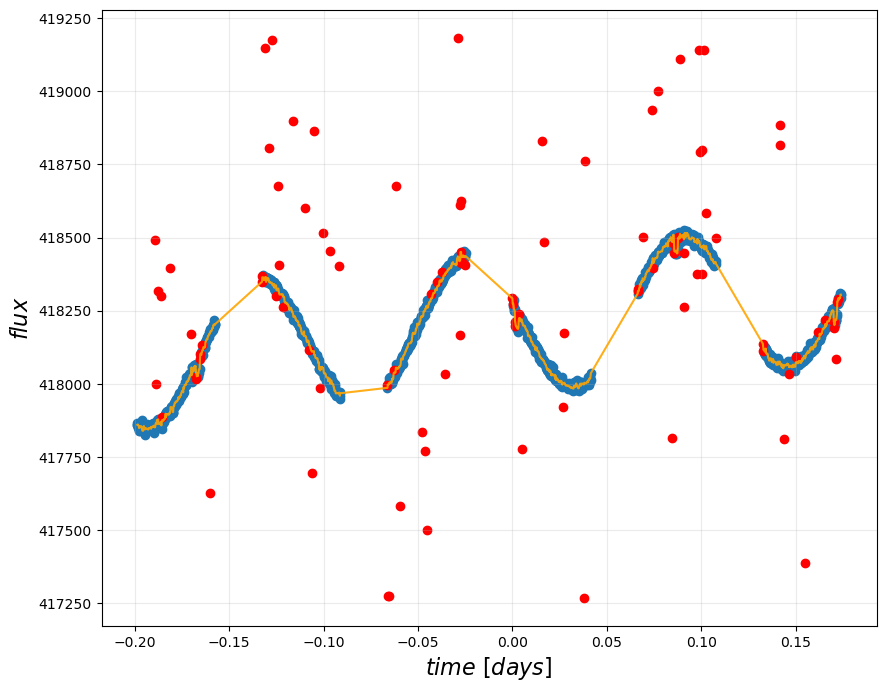

In [239]:
DataDF['edge'] = ((DataDF['flux'] - DataDF['rollingFlux']) / DataDF['fluxErr']).apply(np.abs)

sigma = DataDF['edge'] > 3
DataT = DataDF[~sigma]

plt.figure(figsize=(10,8))
plt.autoscale(enable=True, axis=u'both', tight=False)

plt.scatter(DataT['time'], DataT['flux'])
plt.scatter(DataDF['time'][sigma], DataDF['flux'][sigma], c="r")
plt.plot(DataDF['rollingTime'], DataDF['rollingFlux'], alpha=0.9, zorder=10, c='orange')

plt.ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)
plt.grid(True, alpha=0.25)

plt.savefig("OutlierID.png", dpi=300)

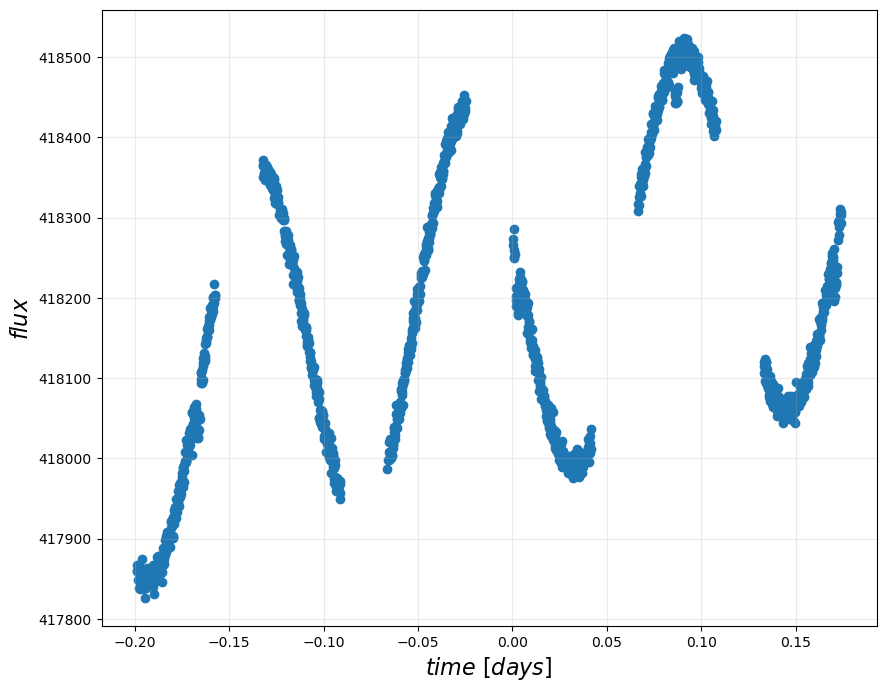

In [240]:
plt.figure(figsize=(10,8))
plt.autoscale(enable=True, axis=u'both', tight=False)

plt.scatter(DataT['time'], DataT['flux'])

plt.ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)
plt.grid(True, alpha=0.25)

plt.savefig("NoOutliers.png", dpi=300)

poly1d([   626.6922768 , 418178.18538578])

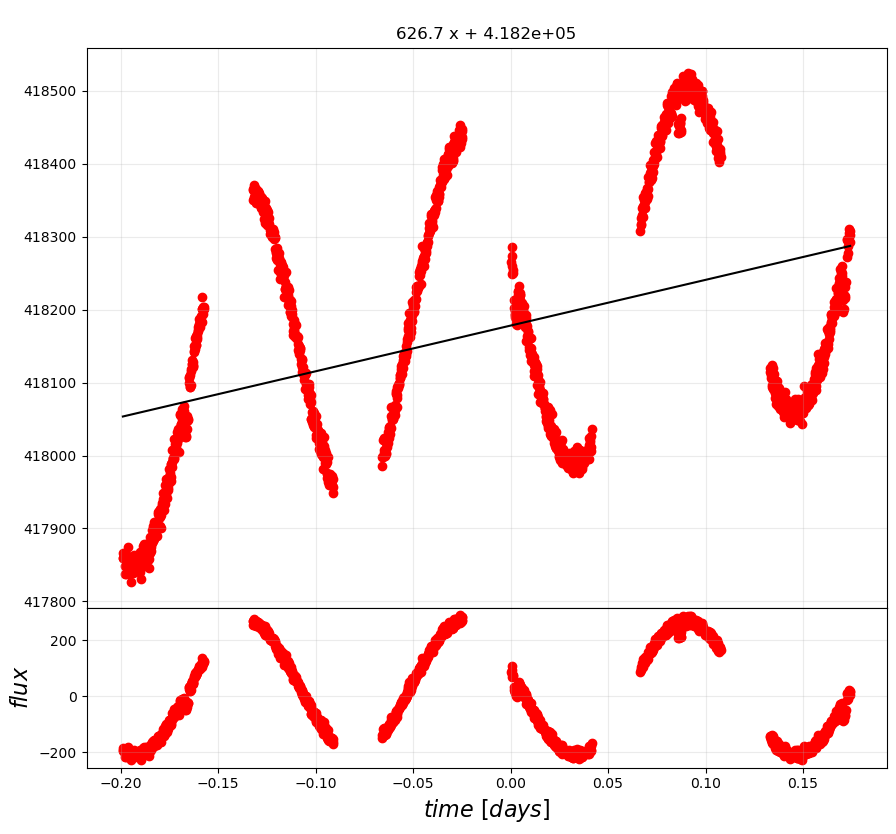

In [241]:
# UNWEIGHTED 1D LINEAR REGRESSION & RESIDUALS

plt.figure(figsize=(10,8))

# FIRST FRAME DRAWS THE PREVIOUS DATA AND A 1D LINEAR REGRESSION
fig1 = plt.figure(1)
frame1=fig1.add_axes((.1,.3,.8,.7))

coef = np.polyfit(DataT['time'], DataT['flux'], 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(DataT['time'], poly1d_fn(DataT['time']), color='k')
plt.scatter(DataT['time'], DataT['flux'], color='r')
#plt.errorbar(DataT['time'], DataT['flux'], yerr=DataT['fluxErr'], fmt="o", capsize=3, alpha=0.25, c='r')

#plt.ylabel('$flux$',fontsize=16)
plt.autoscale(enable=True, axis=u'both', tight=False)
plt.grid(True, alpha=0.25)
plt.title(poly1d_fn)

# SECOND FRAME DRAWS THE RESIDUALS FROM THE PROJECTED LINEAR REGRESSION
frame2=fig1.add_axes((.1,.1,.8,.20))

res = DataT['flux'] - poly1d_fn(DataT['time']) # CALLS THE FUNCTION OF THE LINEAR REGR
#plt.axhline(y=0, color='k', linestyle=':') # DRAWS A HORIZONTAL DASHED LINE WHEN RESIDUALS ARE ZERO
#plt.errorbar(DataT['time'], res, yerr=DataT['fluxErr'], fmt="o", capsize=3, alpha=0.25, c='r')
plt.scatter(DataT['time'], res, color='r')

frame2.set_ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)
plt.grid(True, alpha=0.25)

plt.savefig("PolyFit.png", dpi=300)

poly1d_fn

Best Period = 0.1130062547796928 [days]
Best Amp = 233.34685354816426


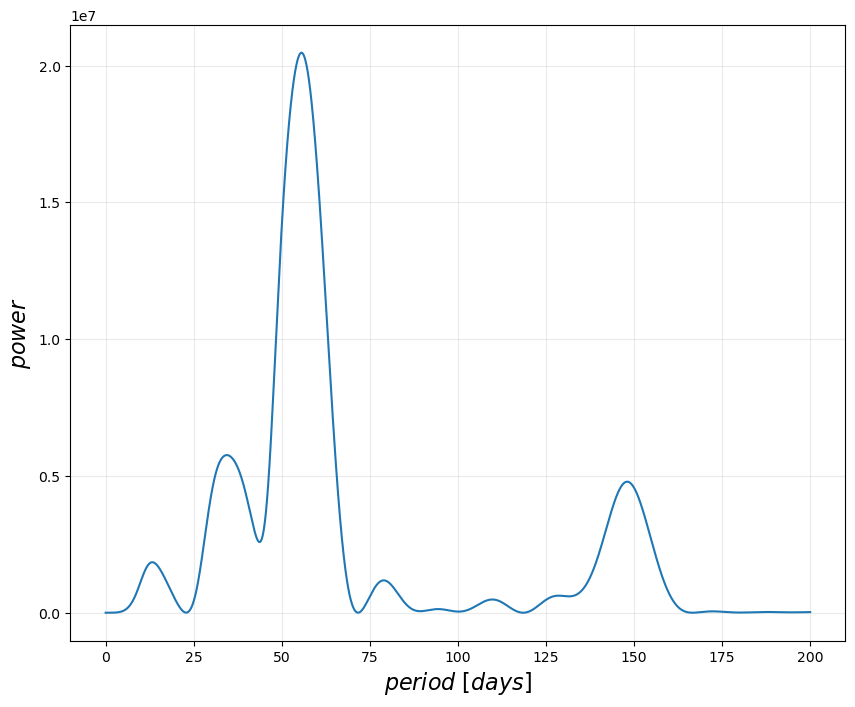

In [242]:
# Detrending LS

nfreq = 50000
angfreqs = np.linspace(0.01, 200, nfreq)

pgram = signal.lombscargle(DataT['time'], res, angfreqs)

Pbest = (2.0  * np.pi) / angfreqs[np.argmax(pgram)]
Abest = np.sqrt(4.0 * pgram[np.argmax(pgram)] / len(DataT['time']))

plt.figure(figsize=(10,8))
plt.plot(angfreqs, pgram)
plt.xlabel('$period$ [$days$]',fontsize=16)
plt.ylabel('$power$',fontsize=16)
plt.grid(True, alpha=0.25)

# returns the inverse of the frequency (i.e. the period) of the largest periodogram value
print("Best Period = " + str(Pbest) + " [days]")
print("Best Amp = " + str(Abest))

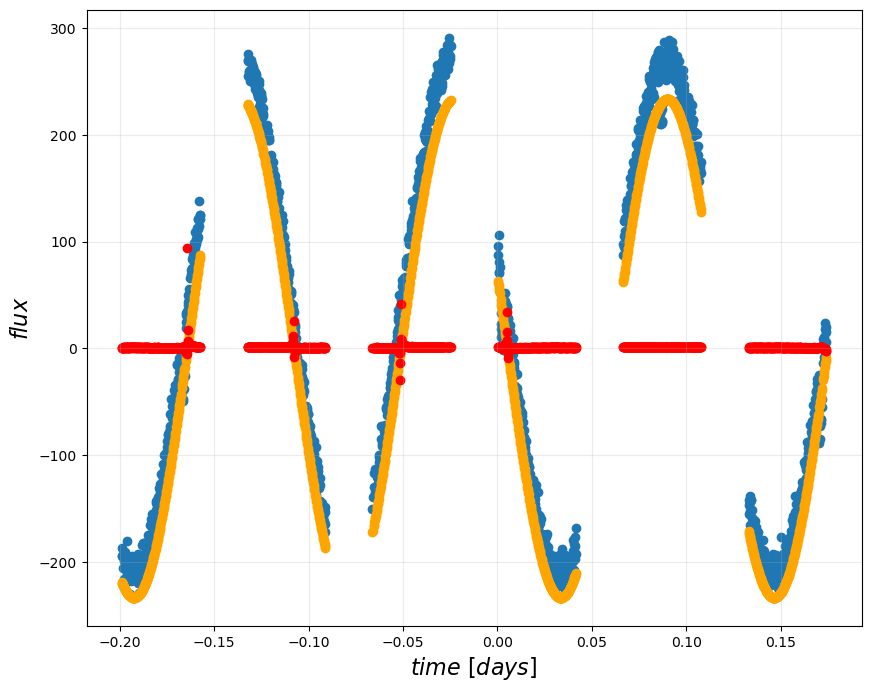

In [243]:
phase = 2.85

Min = np.min(DataT['time'])
Max = np.max(DataT['time'])
timeseries = np.arange(Min, Max, 0.001)

#fittedSine = Abest * np.sin(2.0*np.pi*timeseries/Pbest + phase)
fittedSine = Abest * np.sin(2.0*np.pi*DataT['time']/Pbest + phase)


plt.figure(figsize=(10,8))
plt.scatter(DataT['time'], res)
plt.scatter(DataT['time'], fittedSine, c='orange')
plt.scatter(DataT['time'], res / fittedSine, c='r')

plt.ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)
plt.grid(True, alpha=0.25)

100%|███████████████████████████████████| 99999/99999 [00:10<00:00, 9389.96it/s]


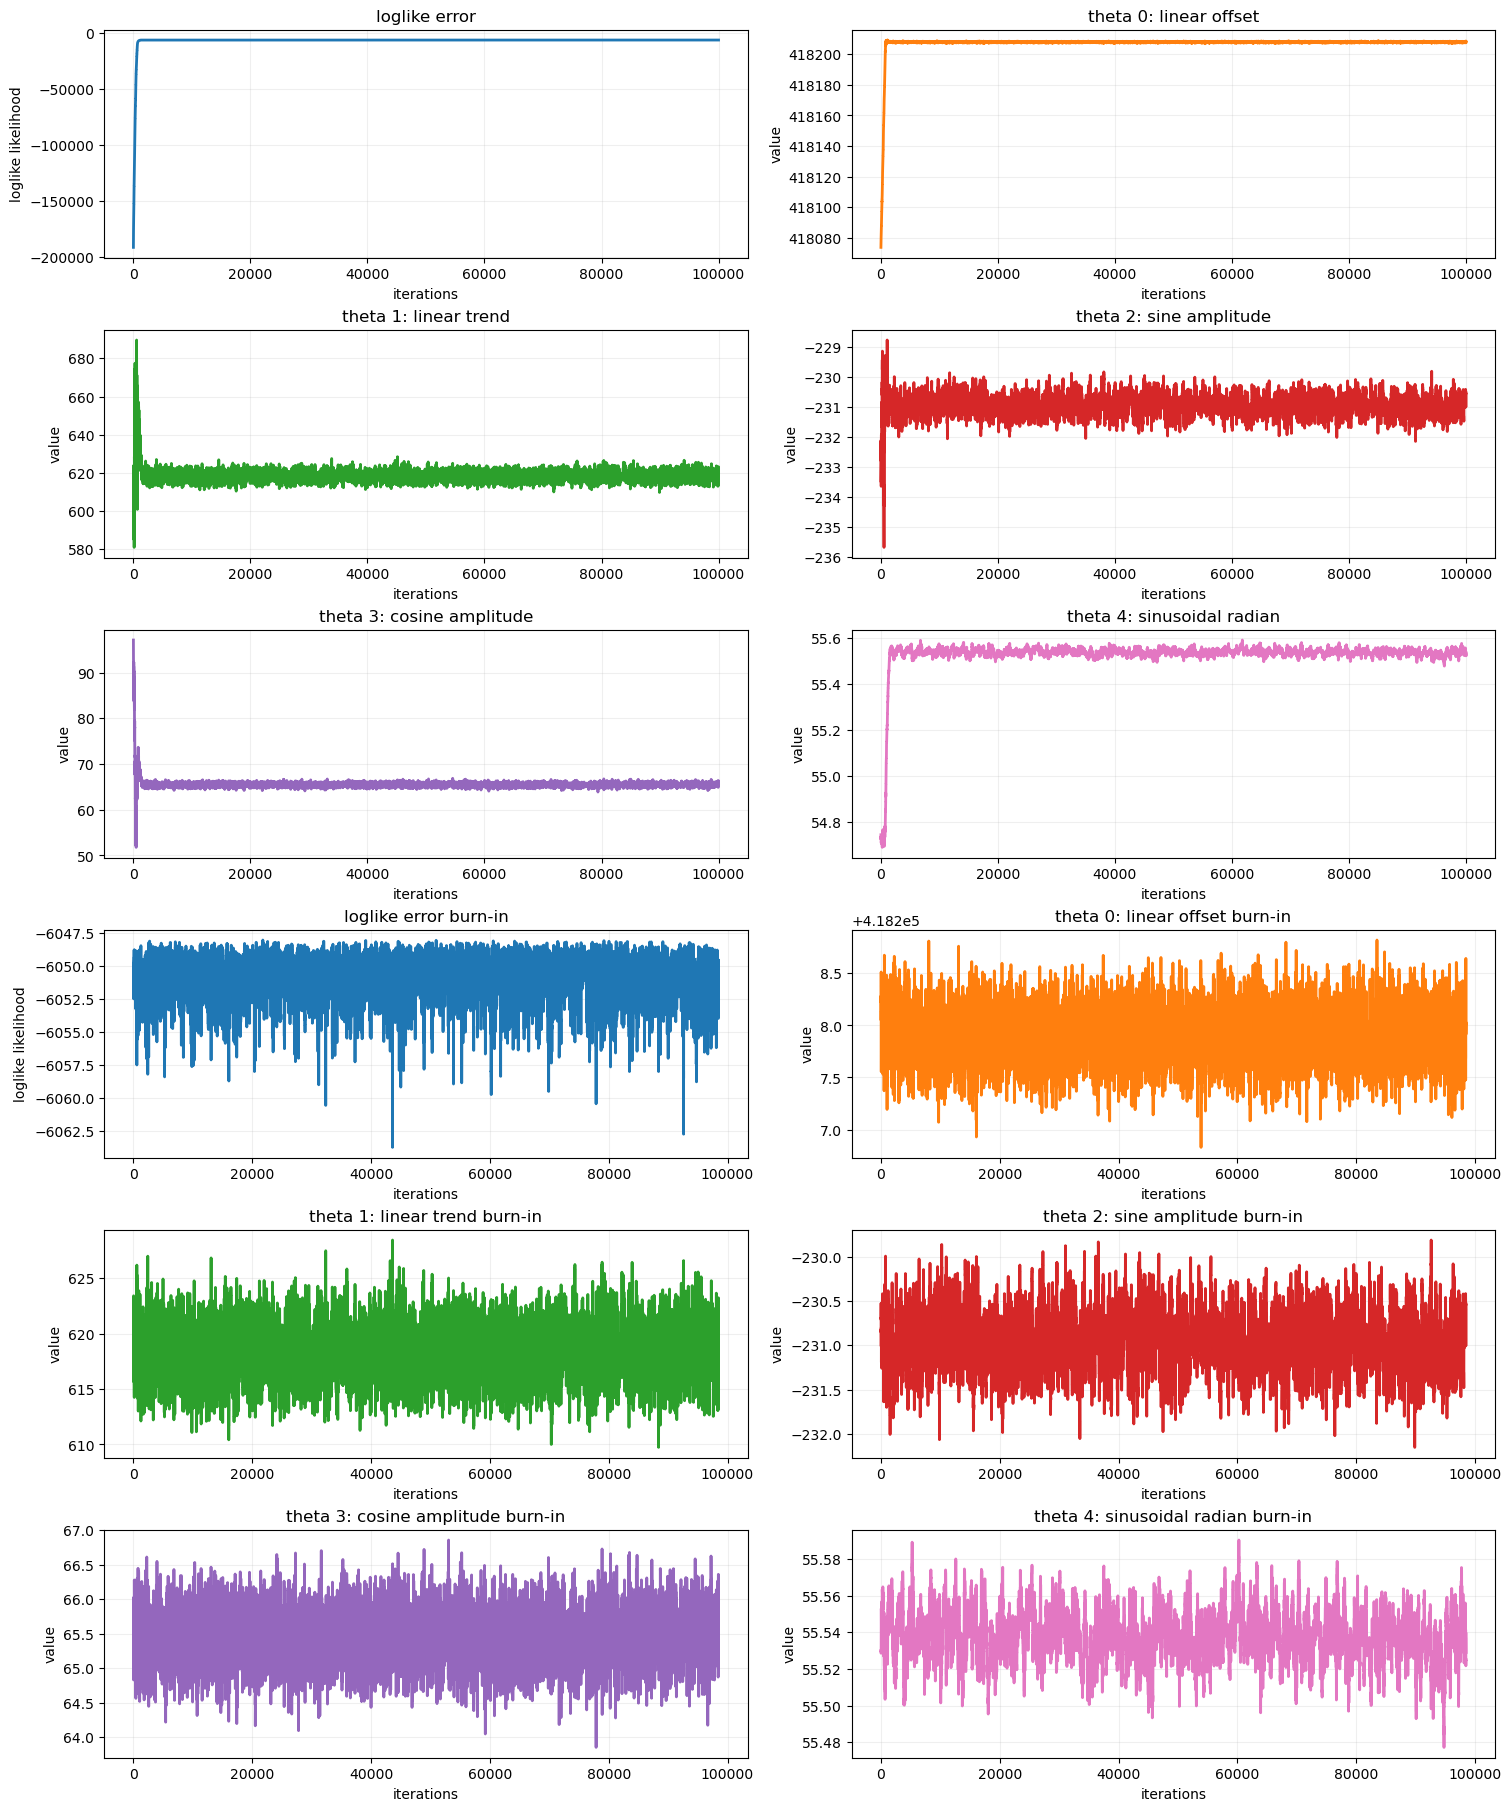

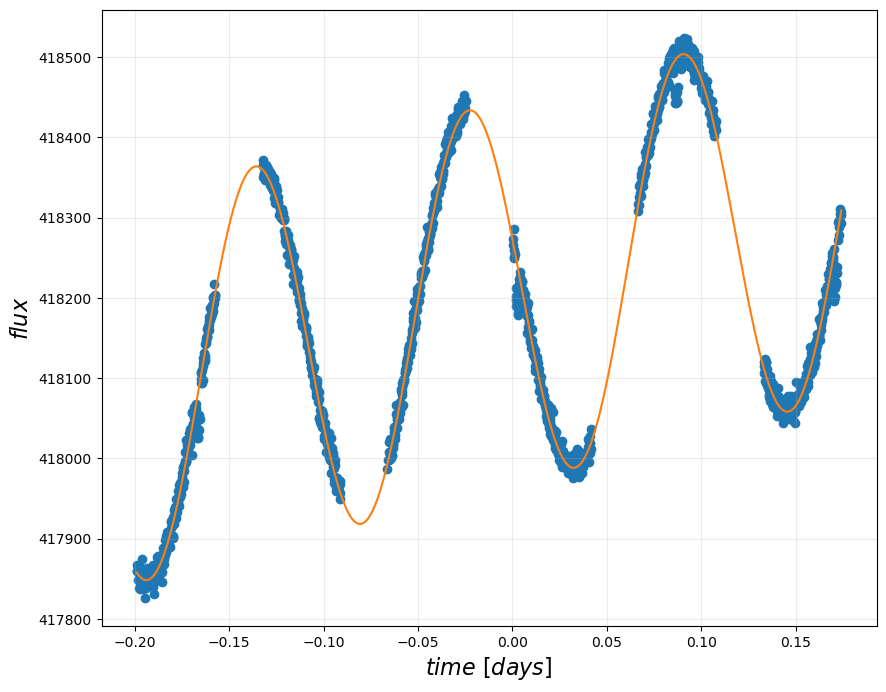

In [244]:
bestRad = 2.0*np.pi/Pbest
bestYint = poly1d_fn[0]
bestM = poly1d_fn[1]

theta = np.array([bestYint, bestM, Abest, Abest, bestRad])
t = np.array(DataT['time'])
f = np.array(DataT['flux'])
fErr = np.array(DataT['fluxErr'])

def model(t, theta):
    return theta[0] + theta[1]*t + theta[2]*np.sin(theta[4] * t) + theta[3]*np.cos(theta[4] * t)

def loglike(t, f, fErr, theta):
    modflux = model(t, theta)
    resid = (f - modflux) / fErr
    loglike = np.sum(-0.5*np.log(2*np.pi) - np.log(fErr) - 0.5*resid**2)
    return loglike

def log_prior(theta, thetaspace):
    logprior = np.zeros(theta.shape[0])
    
    logprior += np.where((theta[0] >= thetaspace[0][0]) & (theta[0] < thetaspace[0][1]), 
                         np.log(1/(thetaspace[0][1]-thetaspace[0][0])), 
                         1e-50000)
    logprior += np.where((theta[1] >= thetaspace[1][0]) & (theta[1] < thetaspace[1][1]), 
                         np.log(1/(thetaspace[1][1]-thetaspace[1][0])), 
                         1e-50000)
    logprior += np.where((theta[2] >= thetaspace[2][0]) & (theta[2] < thetaspace[2][1]), 
                         np.log(1/(thetaspace[2][1]-thetaspace[2][0])), 
                         1e-50000)
    logprior += np.where((theta[3] >= thetaspace[3][0]) & (theta[3] < thetaspace[3][1]), 
                         np.log(1/(thetaspace[3][1]-thetaspace[3][0])), 
                         1e-50000)
    logprior += np.where((theta[4] >= thetaspace[4][0]) & (theta[4] < thetaspace[4][1]), 
                         np.log(1/(thetaspace[4][1]-thetaspace[4][0])), 
                         1e-50000)
    
    return np.sum(logprior)

# Initialize the MCMC from a random point drawn from the prior

#theta = np.array([bestYint, bestM, Abest, Abest, bestRad])

#linear offset
min0, max0 = 418000, 418100

#linear trend
min1, max1 = 575, 675

#sine amplitude
min2, max2 = -300, -200

#cosine amplitude
min3, max3 = -100, 100

#sinusoidal radian
min4, max4 = 50, 60

prior_params = np.array((min0, max0, min1, max1, min2, max2, min3, max3, min4, max4)).reshape(5, 2)

theta0 = np.random.uniform(min0, max0)
theta1 = np.random.uniform(min1, max1)
theta2 = np.random.uniform(min2, max2)
theta3 = np.random.uniform(min3, max3)
theta4 = np.random.uniform(min4, max4)

theta = np.array([theta0, theta1, theta2, theta3, theta4])

mod_loglike = loglike(t, f, fErr, theta)
mod_logp = mod_loglike + log_prior(theta, prior_params)

# Define proposal jump size:
delta = np.array([theta0/1000000, theta1/100, theta2/1000, theta3/100, theta4/10000])

# Start walking
jmax = 100000
theta_j = np.zeros((jmax, 5))
loglike_j = np.zeros(jmax)
logp_j = np.zeros(jmax)

theta_j[0] = theta
loglike_j[0] = mod_loglike
logp_j[0] = mod_logp

for j in tqdm(range(1, jmax)):
    
    # Generate a proposal with a normal distribution with sigma the previously proposed jump size
    theta_trial = np.random.normal(theta_j[j - 1], np.abs(delta))
    loglike_trial = loglike(t, f, fErr, theta_trial)
    logp_trial = loglike_trial + log_prior(theta_trial, prior_params)

    # Compute Metropolis rule
    if loglike_trial > loglike_j[j - 1] or np.random.rand() < np.exp(loglike_trial - loglike_j[j - 1]):
        theta_j[j] = theta_trial
        loglike_j[j] = loglike_trial
    else:
        theta_j[j] = theta_j[j - 1]
        loglike_j[j] = loglike_j[j - 1]
        logp_j[j] = logp_j[j - 1]

#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = loglike_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if loglike_j[i] > median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []
theta_j_2 = []
theta_j_3 = []
theta_j_4 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    theta_j_2.append(i[2])
    theta_j_3.append(i[3])
    theta_j_4.append(i[4])
    iters = loglike_j[0]

fig, axs = plt.subplots(6, 2, figsize=(15, 18), constrained_layout=True)

axs[0, 0].plot(loglike_j, 'tab:blue', linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, 'tab:orange', linewidth=2)
axs[0, 1].set_title('theta 0: linear offset')
axs[0, 1].set_xlabel('iterations')
axs[0, 1].set_ylabel('value')

axs[1, 0].plot(theta_j_1, 'tab:green', linewidth=2)
axs[1, 0].set_title('theta 1: linear trend')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('value')

axs[1, 1].plot(theta_j_2, 'tab:red', linewidth=2)
axs[1, 1].set_title('theta 2: sine amplitude')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(theta_j_3, 'tab:purple', linewidth=2)
axs[2, 0].set_title('theta 3: cosine amplitude')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('value')

axs[2, 1].plot(theta_j_4, 'tab:pink', linewidth=2)
axs[2, 1].set_title('theta 4: sinusoidal radian')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')

axs[3, 0].plot(loglike_j[burn:], 'tab:blue', linewidth=2)
axs[3, 0].set_title('loglike error burn-in')
axs[3, 0].set_xlabel('iterations')
axs[3, 0].set_ylabel('loglike likelihood')

axs[3, 1].plot(theta_j_0[burn:], 'tab:orange', linewidth=2)
axs[3, 1].set_title('theta 0: linear offset burn-in')
axs[3, 1].set_xlabel('iterations')
axs[3, 1].set_ylabel('value')

axs[4, 0].plot(theta_j_1[burn:], 'tab:green', linewidth=2)
axs[4, 0].set_title('theta 1: linear trend burn-in')
axs[4, 0].set_xlabel('iterations')
axs[4, 0].set_ylabel('value')

axs[4, 1].plot(theta_j_2[burn:], 'tab:red', linewidth=2)
axs[4, 1].set_title('theta 2: sine amplitude burn-in')
axs[4, 1].set_xlabel('iterations')
axs[4, 1].set_ylabel('value')

axs[5, 0].plot(theta_j_3[burn:], 'tab:purple', linewidth=2)
axs[5, 0].set_title('theta 3: cosine amplitude burn-in')
axs[5, 0].set_xlabel('iterations')
axs[5, 0].set_ylabel('value')

axs[5, 1].plot(theta_j_4[burn:], 'tab:pink', linewidth=2)
axs[5, 1].set_title('theta 4: sinusoidal radian burn-in')
axs[5, 1].set_xlabel('iterations')
axs[5, 1].set_ylabel('value')

for ax in axs.flat:
    ax.grid(alpha=0.2)

# RESHAPES DATA INTO MULTIDIM ARRAY
samples = np.array([theta_j_0[burn:], theta_j_1[burn:], theta_j_2[burn:], theta_j_3[burn:], theta_j_4[burn:]])
samples = samples.transpose()

# Extract means of all parameters
means = np.mean(samples, axis=0)

# Put means into variables
linOffsetMean, linTrendMean, sinAmpMean, cosAmpMean, sinusRadMean = means

t = np.array(DataT['time'])
tFinite = np.linspace(t[0], t[-1], 500)

# Compute model using broadcasting
model = (linOffsetMean + linTrendMean*tFinite
         + sinAmpMean*np.sin(sinusRadMean * tFinite) 
         + cosAmpMean*np.cos(sinusRadMean * tFinite)) 

plt.savefig("MCMC.png", dpi=300)

plt.figure(figsize=(10,8))
plt.autoscale(enable=True, axis=u'both', tight=False)

plt.scatter(t, DataT['flux'])
plt.plot(tFinite, model, c='tab:orange')

plt.ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)
plt.grid(True, alpha=0.25)

plt.savefig("MCMCFit.png", dpi=300)


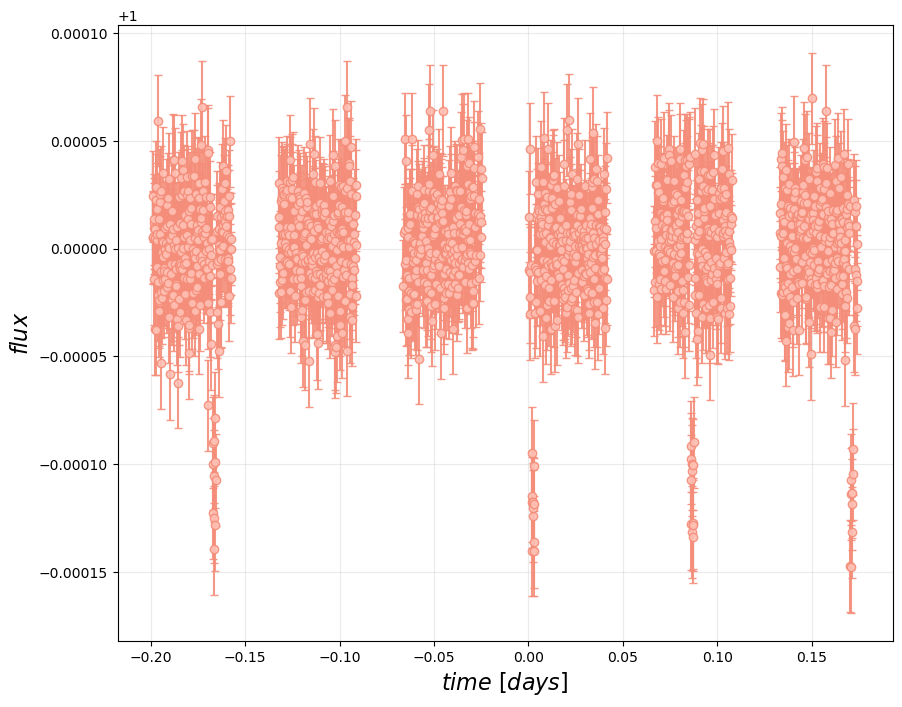

In [245]:
time = np.array(DataT['time'])
timeConv = np.array(DataT['time']) + np.array(tpivot)
flux = np.array(DataT['flux'])
fErr = np.array(DataT['fluxErr'])

model = np.array(linOffsetMean + linTrendMean*time
         + sinAmpMean*np.sin(sinusRadMean * time) 
         + cosAmpMean*np.cos(sinusRadMean * time)) 

detrended = flux / model
fErrConv = fErr / model

plt.figure(figsize=(10,8))
plt.autoscale(enable=True, axis=u'both', tight=False)
#plt.scatter(time, detrended)
plt.errorbar(time, detrended, fErrConv, fmt ='o', capsize = 3, ecolor = '#F48D79', markeredgecolor = '#F48D79',
             markeredgewidth = 1, markerfacecolor = '#FFC0B4', alpha = 0.9)

plt.ylabel('$flux$',fontsize=16)
plt.xlabel('$time$ [$days$]',fontsize=16)
plt.grid(True, alpha=0.25)

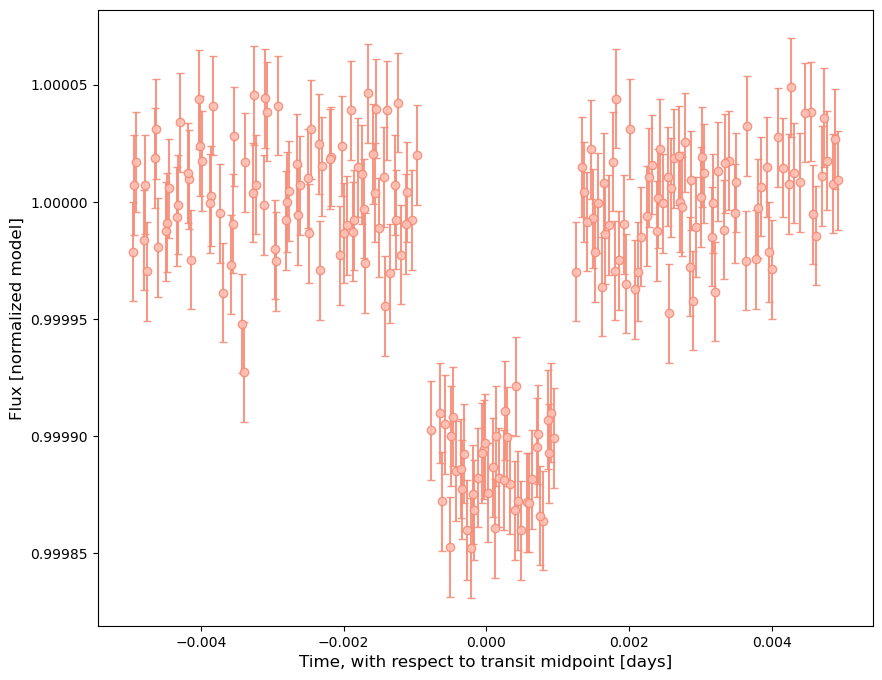

In [246]:
folded_times = []
for t in time:
    if -0.2 < t < -0.15:
        folded_times.append(t - (57531.91792371155 - tpivot))
    elif -0.05 < t < 0.05:
        folded_times.append(t - (57531.91792371155 - tpivot + 2 * 2.025026511149096 / 24))
    elif 0.05 < t < 0.1:
        folded_times.append(t - (57531.91792371155 - tpivot + (3 * 2.025026511149096 / 24)))
    else:
        folded_times.append(t - (57531.91792371155 - tpivot + (4 * 2.025026511149096 / 24)))

final = []
for i in range(len(folded_times)):
    final.append([folded_times[i], detrended[i], fErrConv[i]])
    
data = np.array(final)
cut = []
for arr in data:
    if arr[0] >= -0.005 and arr[0] <= 0.005:
        cut.append(arr)
data_cut = np.array(cut)

plt.figure(figsize=(10,8))
plt.autoscale(enable=True, axis=u'both', tight=False)
plt.errorbar(data_cut[:,0], data_cut[:,1], data_cut[:,2], fmt ='o', capsize = 3, ecolor = '#F48D79', markeredgecolor = '#F48D79',
             markeredgewidth = 1, markerfacecolor = '#FFC0B4', alpha = 0.9)

plt.xlabel('Time, with respect to transit midpoint [days]', fontsize=12)
plt.ylabel('Flux [normalized model]', fontsize=12)
plt.ticklabel_format(useOffset=False)

The transit depth is 0.000117
1.0000023012257837 0.9998850998646591


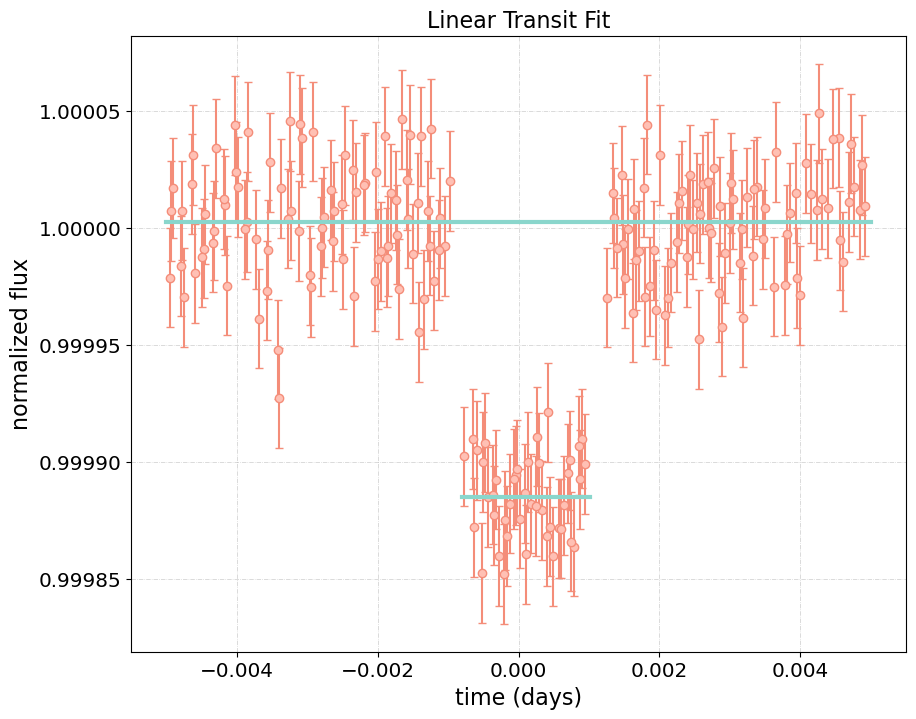

In [247]:
# Differentiate between in-transit data and out-of-transit data
start = -0.0008
end = 0.00101
transit_d = []
selected = []
transit_d = data_cut[(data_cut[:, 0] > start) & (data_cut[:, 0] < end)]
transit_non_d = data_cut[~((data_cut[:, 0] > start) & (data_cut[:, 0] < end))]

# Find the best slope-0 linear fit to the in-transit data
num_points = len(transit_d)
aS = np.linspace(np.amin(transit_d[:,1]), np.amax(transit_d[:,1]), num_points)
loglike = np.sum(-(0.5*np.log(2*np.pi))-(np.log(transit_d[:,2][None, :]))-0.5*(((transit_d[:,1][None, :]-aS[:, None])/transit_d[:,2][None, :])**2), axis=1)
a_max = aS[np.argmax(np.abs(loglike))]

# Find the best slope-0 linear fit to the out-of-transit data
b_max = 0
bs = np.arange(np.amin(transit_non_d[:,1]), np.amax(transit_non_d[:,1]), 0.0000001)
loglikes = np.sum(-(0.5*np.log(2*np.pi))-(np.log(transit_non_d[:,2][None, :]))-0.5*(((transit_non_d[:,1][None, :]-bs[:, None])/transit_non_d[:,2][None, :])**2), axis=1)
b_max = bs[np.argmax(loglikes)]

# Plot the resulting fits
xline = np.linspace(-0.005, 0.005, 100)
yline = np.full((100,), b_max)
xline2 = np.linspace(start, end, 100)
yline2 = np.full((100,), a_max)

fig = plt.figure(figsize=(10,8))
plt.errorbar(transit_d[:,0],transit_d[:,1], transit_d[:,2], fmt ='o', capsize = 3, ecolor = '#F48D79', markeredgecolor = '#F48D79',
             markeredgewidth = 1, markerfacecolor = '#FFC0B4')
plt.errorbar(transit_non_d[:,0],transit_non_d[:,1], transit_non_d[:,2], fmt ='o', capsize = 3, ecolor = '#F48D79', markeredgecolor = '#F48D79', 
             markeredgewidth = 1, markerfacecolor = '#FFC0B4')
line1 = plt.plot(xline, yline, color='#8ad6cc', marker = '', linewidth = 3, zorder=30)
line2 = plt.plot(xline2, yline2, color='#8ad6cc', marker = '', linewidth = 3, zorder=30)

plt.xlabel('time (days)', fontsize=16)
plt.ylabel('normalized flux', fontsize=16)
ax = plt.gca()
ax.grid(color='grey', linestyle='-.', linewidth=0.5, alpha = 0.4)
ax.yaxis.set_tick_params(labelsize='x-large')
ax.xaxis.set_tick_params(labelsize='x-large')

plt.title('Linear Transit Fit', fontsize = 16)
plt.ticklabel_format(useOffset=False)

fig.savefig("FoldedTransitData.png", bbox_inches='tight', dpi=600)

print("The transit depth is {:04.6f}".format(b_max-a_max))
print(b_max, a_max)

In [268]:
# Calculate log(2 * pi)
log2pi = np.log(2 * np.pi)

# Transit
pert_yint_transit = []
for n in range(1000):
    new_pts = np.random.normal(transit_d[:, 1], transit_d[:, 2])
    loglike_max = 0
    a_max = 0
    for a in np.arange(np.amin(new_pts), np.amax(new_pts), 0.000001):
        loglike = -(0.5 * log2pi) - np.log(transit_d[:, 2]) - 0.5 * (((new_pts - a) / transit_d[:, 2]) ** 2)
        loglike_sum = np.sum(loglike)
        if np.abs(loglike_sum) >= loglike_max:
            loglike_max = np.abs(loglike_sum)
            a_max = a
    pert_yint_transit.append(a_max)

# Non-Transit
pert_yint_non_transit = []
for n in range(1000):
    new_pts = np.random.normal(transit_non_d[:, 1], transit_non_d[:, 2])
    loglike_max = 0
    b_max = 0
    for b in np.arange(np.amin(new_pts), np.amax(new_pts), 0.000001):
        loglike = -(0.5 * log2pi) - np.log(transit_non_d[:, 2]) - 0.5 * (((new_pts - b) / transit_non_d[:, 2]) ** 2)
        loglike_sum = np.sum(loglike)
        if loglike_sum >= loglike_max:
            loglike_max = loglike_sum
            b_max = b
    pert_yint_non_transit.append(b_max)

1.0000021248544178 1.7395536222949118e-06


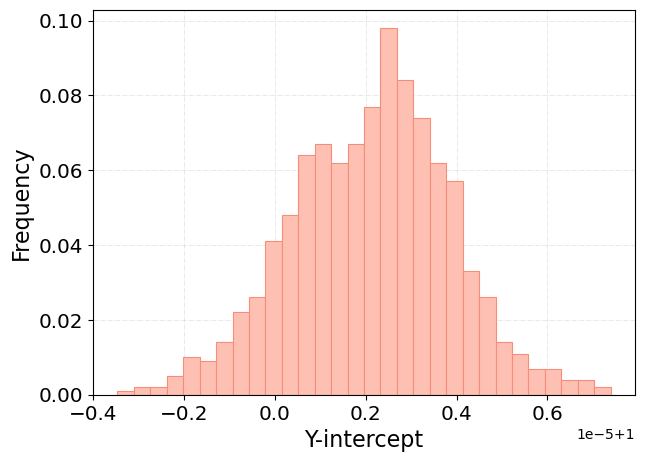

In [269]:
# Histogram of the y-intercept of the non-transit linear fit
fig = plt.figure(figsize=(7,5))
weights = np.ones_like(np.array(pert_yint_non_transit))/float(len(np.array(pert_yint_non_transit)))
plt.hist(np.array(pert_yint_non_transit),weights=weights, bins = 30, facecolor = '#FFC0B4', edgecolor='#F48D79', linewidth=0.8, zorder=2)
mu_non_transit, std_non_transit = norm.fit(pert_yint_non_transit) 
plt.xlabel('Y-intercept', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
ax = plt.gca()
ax.grid(color='grey', linestyle='-.', linewidth=0.5, alpha = 0.25, zorder=0)
ax.xaxis.set_tick_params(labelsize='x-large')
ax.yaxis.set_tick_params(labelsize='x-large')
print(mu_non_transit, std_non_transit)

0.9998852547856536 3.160403286313794e-06


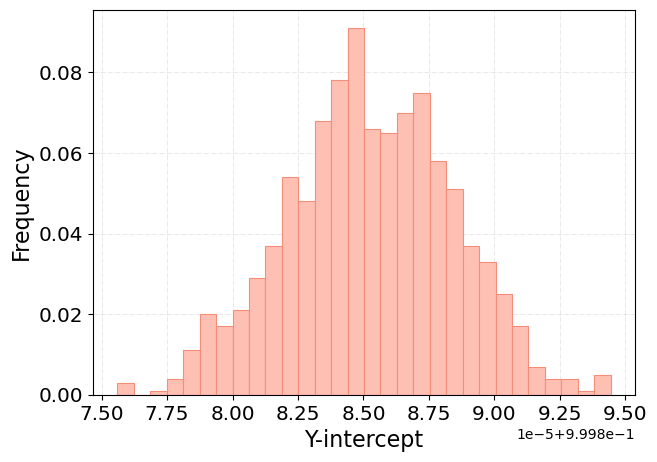

In [270]:
# Histogram of the y-intercept of the non-transit linear fit
fig = plt.figure(figsize=(7,5))
weights = np.ones_like(np.array(pert_yint_transit))/float(len(np.array(pert_yint_transit)))
plt.hist(np.array(pert_yint_transit),weights=weights, bins = 30, facecolor = '#FFC0B4', edgecolor='#F48D79', linewidth=0.8, zorder=2)
mu_transit, std_transit = norm.fit(pert_yint_transit) 
plt.xlabel('Y-intercept', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
ax = plt.gca()
ax.grid(color='grey', linestyle='-.', linewidth=0.5, alpha = 0.25, zorder=0)
ax.xaxis.set_tick_params(labelsize='x-large')
ax.yaxis.set_tick_params(labelsize='x-large')
print(mu_transit, std_transit)

In [283]:
# From the normal estimation of the 
print("The transit depth is {:04.6f} ".format(b_max-a_max) + u"\u00B1" + 
      " {:04.6f}".format(np.sqrt(std_transit**2+std_non_transit**2))+" with respect to the normalized flux")

The transit depth is 0.000117 ± 0.000004 with respect to the normalized flux


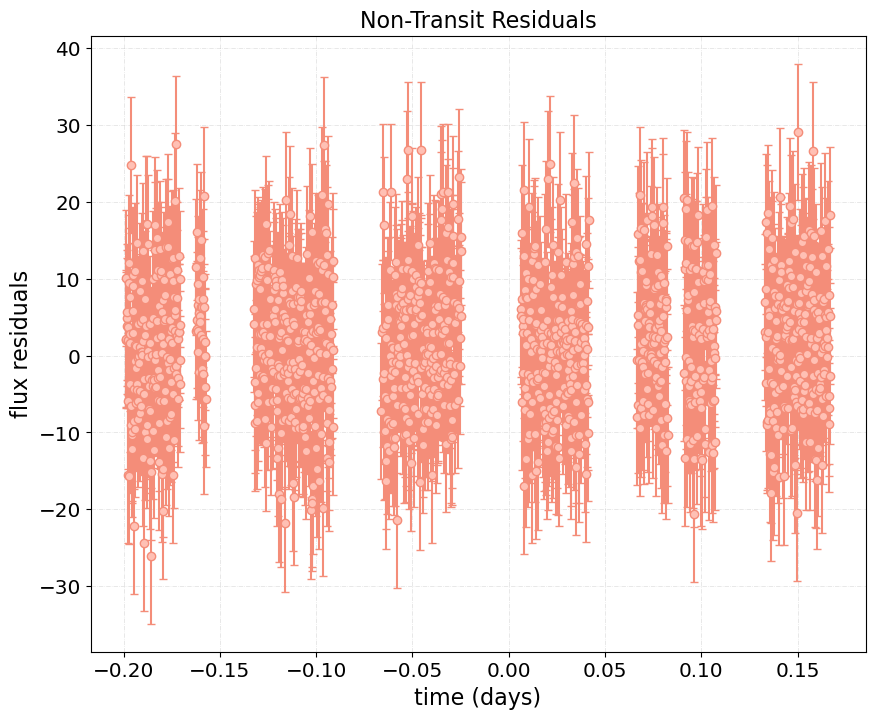

In [252]:
residuals = flux - model

# Define a transit interval (including 0.004 days around the central transit time)
def transit_time_inter(first_central_transit_t, transit_period):
    return [(transit_mean_t - 0.004, transit_mean_t + 0.004) for transit_mean_t in (
        first_central_transit_t + n * transit_period for n in range(5))]

# Find the transits knowing the center of the first transit and their periodicity
first_central_transit_t = 57531.91792371155 - tpivot
first_central_transit_t
transit_intervals = transit_time_inter(first_central_transit_t, 2.025026511149096 / 24)

# Define a time-flux array for non-transit and transit periods, respectively
transit_rows = []
for a in range(len(time)):
    for b in range(5):
        if time[a] >= transit_intervals[b][0] and time[a] < transit_intervals[b][1]:
            transit_rows.append(a)
transit_rows = np.array(transit_rows)
total = np.array(list(range(len(time))))

selected = np.setdiff1d(total, transit_rows)

non_transit_tf = time[selected]
resid = residuals[selected]
fErrSel = fErr[selected]
transit_tf = time[transit_rows]

fig = plt.figure(figsize=(10,8))
plt.errorbar(non_transit_tf, np.array(resid), fErrSel, fmt ='o', capsize = 3, ecolor = '#F48D79', markeredgecolor = '#F48D79', markeredgewidth = 1, markerfacecolor='#FFC0B4')
plt.xlabel('time (days)', fontsize=16)
plt.ylabel('flux residuals', fontsize=16)
ax = plt.gca()
ax.grid(color='grey', linestyle='-.', linewidth=0.5, alpha = 0.25, zorder=0)
ax.xaxis.set_tick_params(labelsize='x-large')
ax.yaxis.set_tick_params(labelsize='x-large')
plt.title('Non-Transit Residuals', fontsize = 16)


plt.savefig("residualsNONT.png", dpi=300)


In [253]:
# Calculation of the chi2 value for the fit
chi2_data = 0
for i in range(len(resid)):
    chi2_data += (resid[i]/fErrSel[i])**2
print("The chi2 value for this fit is {:04.2f}".format(float(chi2_data)) + " for a number of datapoints of {}".format(len(residuals)))

The chi2 value for this fit is 1328.44 for a number of datapoints of 1504


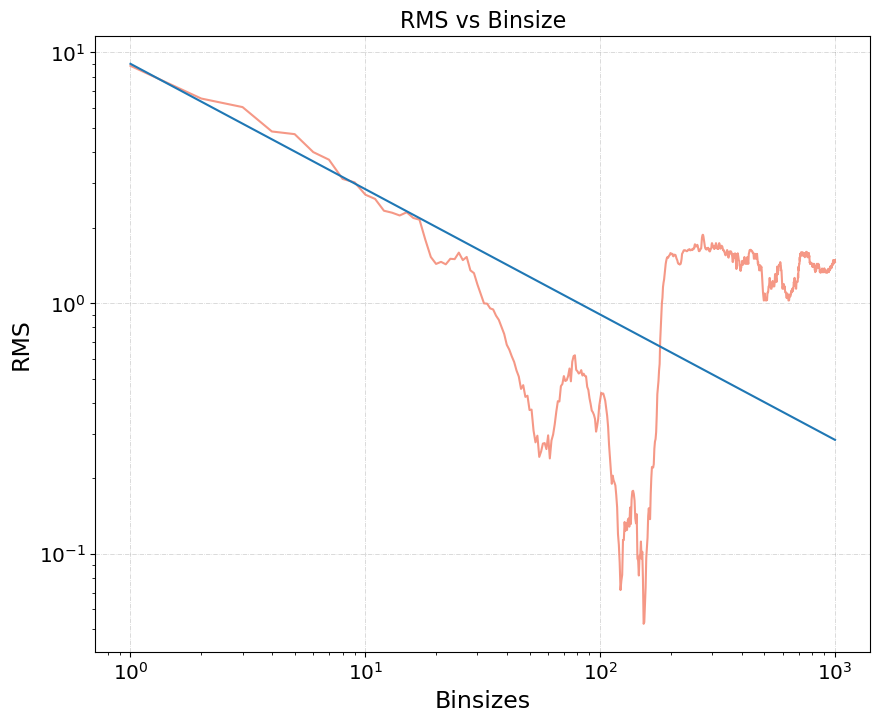

In [254]:
# Pre-calculate binning_median for all binsizes
bin_medians = [binning_median(resid, n) for n in range(1, 1000)]

# Calculation of the rms
rms_total = np.zeros(len(bin_medians))
for i in range(len(bin_medians)):
    binned_data = np.asarray(bin_medians[i])
    temp = np.sum(binned_data**2)
    rms_total[i] = np.sqrt(temp/len(binned_data))

# Plotting RMS vs binsize
fig = plt.figure(figsize=(10,8))
xrange = np.arange(1, 1000, 1)

plt.plot(binszs,rms_total, color = '#F48D79', alpha = 0.9)
plt.xlabel('Binsizes', fontsize=17)
plt.ylabel('RMS', fontsize=17)
plt.plot(xrange, 9 * xrange**(-0.5))
ax = plt.gca()
ax.grid(color='grey', linestyle='-.', linewidth=0.5, alpha = 0.4)
ax.yaxis.set_tick_params(labelsize='x-large')
ax.xaxis.set_tick_params(labelsize='x-large')
ax.set_xscale('log')
ax.set_yscale('log')

plt.title('RMS vs Binsize', fontsize = 16)
plt.show()
fig.savefig("RMSvsBinsize.png", bbox_inches='tight', dpi=600)

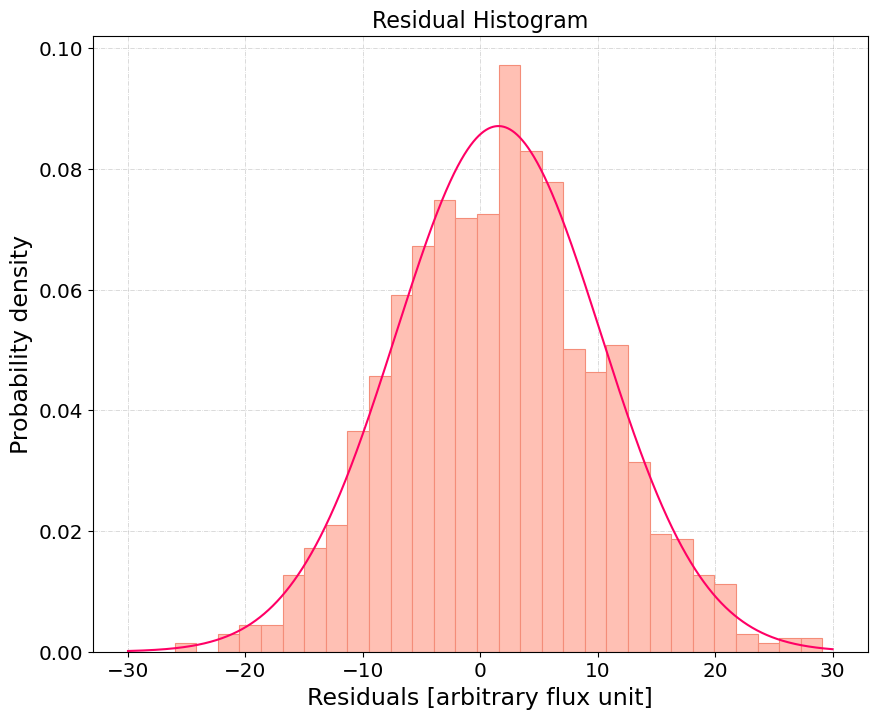

The residuals roughly follow a normal distribution with mean 1.5414050918812314, and SD, 8.700485408474815


In [255]:
# Lastly, plot the histogram of residuals, and superimpose a normal distribution to check that it follows one.
fig = plt.figure(figsize=(10,8))

weights = np.ones_like(np.array(resid))/len(resid)
plt.hist(np.array(resid), weights = weights, bins = 30, facecolor = '#FFC0B4', edgecolor='#F48D79', linewidth=0.8, zorder =2)

plt.xlabel('Residuals [arbitrary flux unit]', fontsize=17)
plt.ylabel('Probability density', fontsize=17)
ax = plt.gca()
ax.grid(color='grey', linestyle='-.', linewidth=0.5, alpha = 0.4)
ax.yaxis.set_tick_params(labelsize='x-large')
ax.xaxis.set_tick_params(labelsize='x-large')

mu_residuals, std_residuals = norm.fit(resid) 
x_axis = np.arange(-30, 30, 0.01)
plt.plot(x_axis, 1.9*norm.pdf(x_axis, mu_residuals, std_residuals), color = "#ff0065")

plt.title('Residual Histogram', fontsize = 16)
plt.show()

fig.savefig("HistogramResiduals.png", bbox_inches='tight', dpi=600)
print("The residuals roughly follow a normal distribution with mean {}, and SD, {}".format(mu_residuals, std_residuals))